<a href="https://colab.research.google.com/github/AdarkarRavaji2004/CSL701-CS01_Machine-Learning-Lab/blob/main/Experiments/ML_Exp_No_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Ravaji Parshuram Adarkar  
**Roll No.:** CS01

**Aim:** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# Load Auto MPG Dataset
df = pd.read_csv("/content/auto-mpg.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [30]:
# Inspect Dataset
print("Dataset Information")
print(df.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horsepower  392 non-null    float64
 1   mpg         392 non-null    float64
dtypes: float64(2)
memory usage: 9.2 KB
None


In [34]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
horsepower    0
mpg           0
dtype: int64


In [35]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(392, 2)


In [36]:
# Clean the Data
df = df[['horsepower', 'mpg']].dropna()

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna()

print("Cleaned Dataset Shape:", df.shape)
df.head()

Cleaned Dataset Shape: (392, 2)


,horsepower,mpg
0,130.0,18.0
1,165.0,15.0
2,150.0,18.0
3,150.0,16.0
4,140.0,17.0


In [37]:
# Select Horsepower and MPG
X = df['horsepower'].values
Y = df['mpg'].values

print("Horsepower:")
print(X[:5])

print("\nMPG:")
print(Y[:5])

Horsepower:
[130. 165. 150. 150. 140.]

MPG:
[18. 15. 18. 16. 17.]


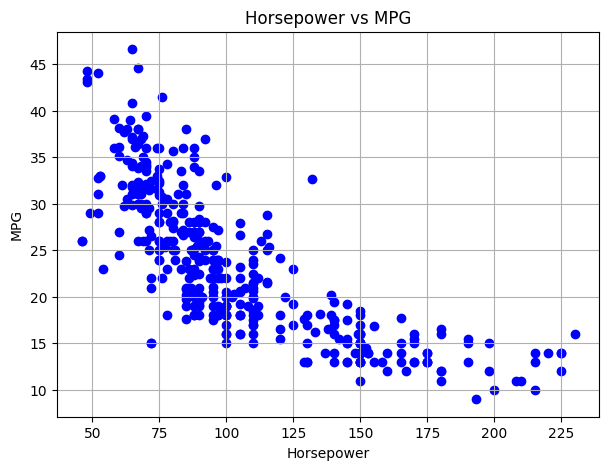

In [38]:
# Scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue')
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.grid(True)
plt.show()

In [39]:
# Add Bias (Intercept) Term
X_bias = np.c_[np.ones(len(X)), X]

print("First Five Rows of X with Bias:")
print(X_bias[:5])

First Five Rows of X with Bias:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


In [40]:
# Compute Correlation
correlation = np.corrcoef(X, Y)[0,1]

print("Correlation Coefficient =", correlation)

Correlation Coefficient = -0.7784267838977756


In [41]:
# Calculate OLS Weights
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

intercept = weights[0]
slope = weights[1]

print("Intercept =", intercept)
print("Slope =", slope)

Intercept = 39.9358610211705
Slope = -0.15784473335365387


In [42]:
# Predict MPG Values
Y_pred = X_bias @ weights

print("First Five Predicted Values:")
print(Y_pred[:5])

First Five Predicted Values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835]


In [43]:
# Compute Residuals
residuals = Y - Y_pred

print("First Five Residuals:")
print(residuals[:5])

First Five Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835]


In [44]:
# Calculate SSE, MSE, and R²
SSE = np.sum((Y - Y_pred) ** 2)
MSE = np.mean((Y - Y_pred) ** 2)

R2 = 1 - (SSE / np.sum((Y - np.mean(Y)) ** 2))

print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


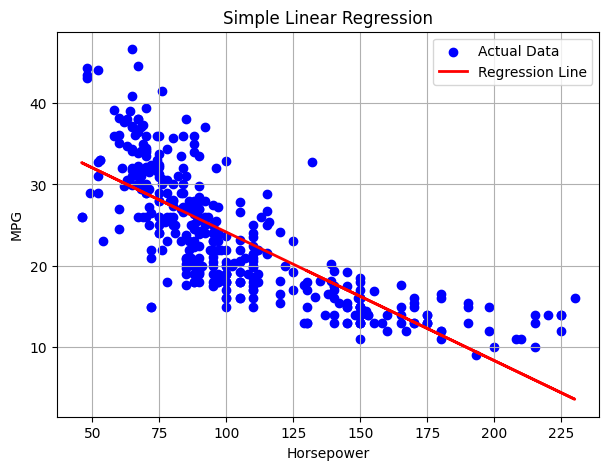

In [45]:
# Plot Regression Line
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue', label="Actual Data")
plt.plot(X, Y_pred, color='red', linewidth=2, label="Regression Line")

plt.title("Simple Linear Regression")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()
plt.grid(True)
plt.show()

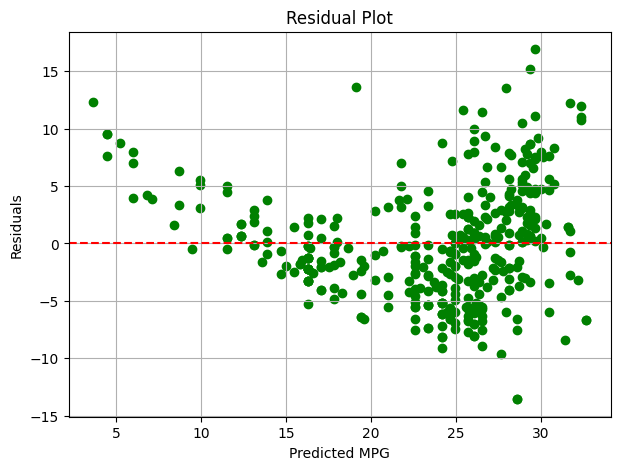

In [46]:
# Residual Plot
plt.figure(figsize=(7,5))
plt.scatter(Y_pred, residuals, color='green')

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()